# CSEM exercise

Created by Michele Paulatto, Imperial College London

https://github.com/michpaulatto/AppliedGeophysicsExercises


Version 2.0 - 28.01.2025

This exercise is distributed under a [GNU GPL 3.0 license](https://www.gnu.org/licenses/gpl-3.0.en.html).

![](https://www.gnu.org/graphics/gplv3-with-text-136x68.png)

Developed for [Google Colab](https://colab.research.google.com/)



#Environment setup

We need to set up the Python environment before we start. If running the exercise on your local machine the setup would have to be modified. We need to install Anaconda (https://www.anaconda.com/) and use it to install SegyIO. Some of the operations in the setup are a bit advanced and are beyond the scope of this exercise. So just run the following two code cells and move on. This may take a couple of minutes so be patient. If running this Notebook on Google Colab for the first time you may get a warning that the Notebook was not authored by Google, click OK and continue.

In [1]:
!pip install -q "condacolab==0.1.3"
import condacolab
condacolab.install_from_url("https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh")

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:22
🔁 Restarting kernel...


In [1]:
import condacolab
condacolab.check()
!mamba install -c prisae empymod --yes >& log.out
print("modules installed")

✨🍰✨ Everything looks OK!

Looking for: ['empymod']

[+] 0.0s
[+] 0.1s
prisae/linux-64 (c..  ⣾  prisae/linux-64 (check zst)                       
[+] 0.0s
[+] 0.1s
prisae/noarch (che..  ⣾  prisae/noarch (check zst)                         
[+] 0.0s
prisae/linux-64  ⣾  [+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch     1%
prisae/linux-64       ⣾  
prisae/noarch         ⣾  prisae/noarch                                     
[+] 0.2s
conda-forge/linux-64   5%
conda-forge/noarch     9%
prisae/linux-64       ⣾  [+] 0.3s
conda-forge/linux-64  11%
conda-forge/noarch    24%
prisae/linux-64       ⣾  [+] 0.4s
conda-forge/linux-64  17%
conda-forge/noarch    38%
prisae/linux-64       ⣾  [+] 0.5s
conda-forge/linux-64  23%
conda-forge/noarch    51%
prisae/linux-64       ⣾  [+] 0.6s
conda-forge/linux-64  25%
conda-forge/noarch    56%
prisae/linux-64       ⣾  [+] 0.7s
conda-forge/linux-64  29%
conda-forge/noarch    63%
prisae/linux-64       ⣾  [+] 0.8s
conda-forge/linux-64  30%
conda-forge/noarc

# Import modules and setup environment
Here we import the Python modules that we need for the exercise.



In [3]:
import empymod
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

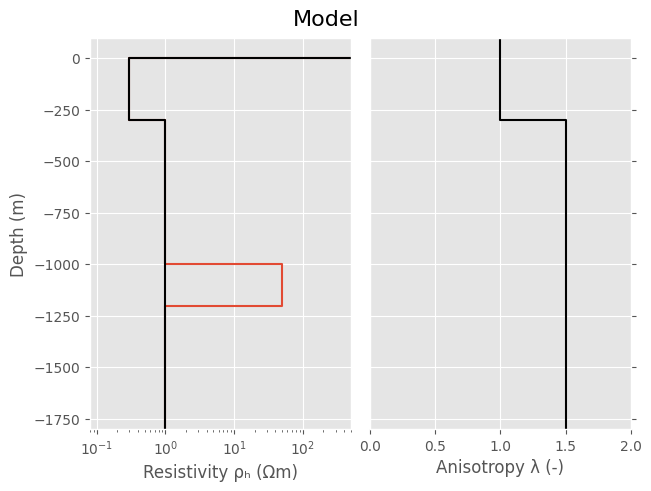

In [5]:
depth = [0, -300, -1000, -1200]  # Layer boundaries
res_tg = [2e14, 0.3, 1, 50, 1]   # Anomaly resistivities
res_bg = [2e14, 0.3, 1, 1, 1]    # Background resistivities
aniso = [1, 1, 1, 1, 1]    # Layer anisotropies (same for entire model)

p_depth = np.repeat(np.r_[100, depth, 2*depth[-1]], 2)[1:-1]

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, sharey=True)
fig.suptitle("Model", fontsize=16)

# Plot Resistivities
ax1.semilogx(np.repeat(res_tg, 2), p_depth, 'C0')
ax1.semilogx(np.repeat(res_bg, 2), p_depth, 'k')
ax1.set_xlim([0.08, 500])
ax1.set_ylim([-1800, 100])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel('Resistivity ρₕ (Ωm)')

# Plot anisotropies
ax2.plot(np.repeat(aniso, 2), p_depth, 'k')
ax2.set_xlim([0, 2])
ax2.set_xlabel('Anisotropy λ (-)')
ax2.yaxis.tick_right()

